# Task 7: Customer Segmentation Using Unsupervised Learning

## DevelopersHub Corporation – Data Science & Analytics Internship

### Objective

The objective of this project is to segment mall customers into distinct groups based on their purchasing behavior using K-Means Clustering. Customer segmentation helps businesses understand different customer profiles, enabling personalized marketing strategies and better customer relationship management.

### Learning Outcomes

- Perform Exploratory Data Analysis (EDA)
- Apply K-Means Clustering
- Determine optimal number of clusters
- Visualize clusters using PCA
- Interpret customer segments
- Develop business-oriented marketing strategies

# Import Required Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_style("whitegrid")

# Display settings
pd.set_option('display.max_columns', None)

# Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Dataset Description

The dataset contains customer demographic information and spending behavior collected from mall visitors.

### Features

- CustomerID
- Gender
- Age
- Annual Income (k$)
- Spending Score (1-100)

The Spending Score is assigned by the mall based on customer purchasing behavior and spending patterns.

# Dataset Shape

In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.shape

Rows : 200
Columns : 5


(200, 5)

# Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# Summary Statistics

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


# Checking Missing Values

In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Observation

There are no missing values in the dataset.

The dataset is complete and ready for analysis.

# Checking Duplicate Records

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Observation
No duplicate observations were found.

# Checking Data Types

In [8]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

## Initial Observations

- Dataset contains 200 customers.
- No missing values.
- No duplicate rows.
- Only Gender is categorical.
- CustomerID acts as an identifier and will not be used for clustering.
- Annual Income and Spending Score are expected to be the most influential features for segmentation.

# Exploratory Data Analysis (EDA)

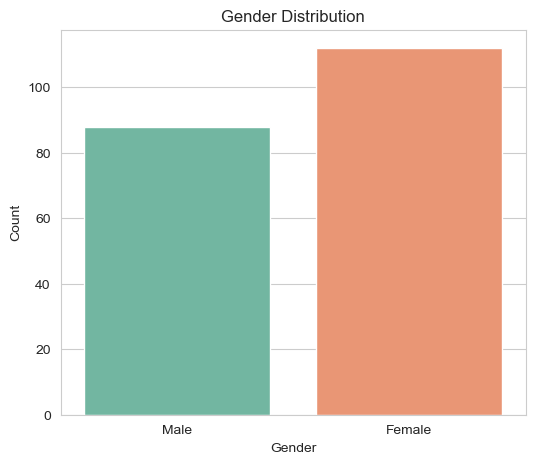

In [9]:
# Distribution of Customer Gender
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Gender', palette='Set2')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

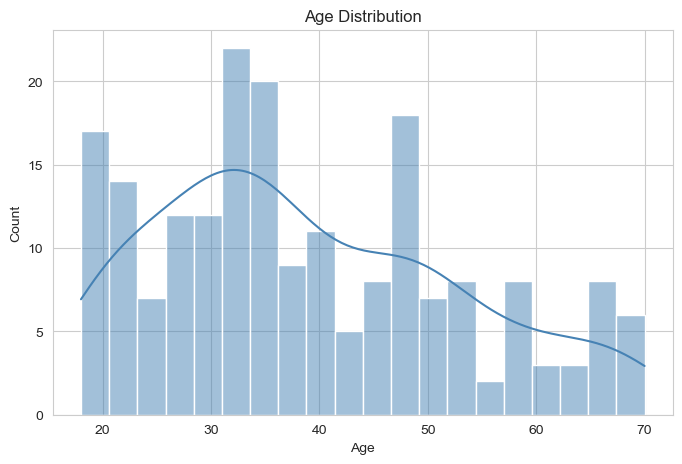

In [10]:
# Distribution of Customer Age
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True, color="steelblue")

plt.title("Age Distribution")

plt.show()

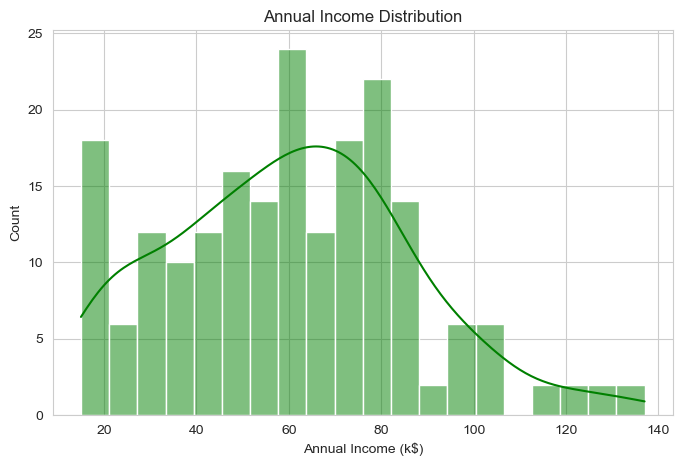

In [11]:
# Distribution of Annual Income
plt.figure(figsize=(8,5))

sns.histplot(df["Annual Income (k$)"],
             bins=20,
             kde=True,
             color="green")

plt.title("Annual Income Distribution")

plt.show()

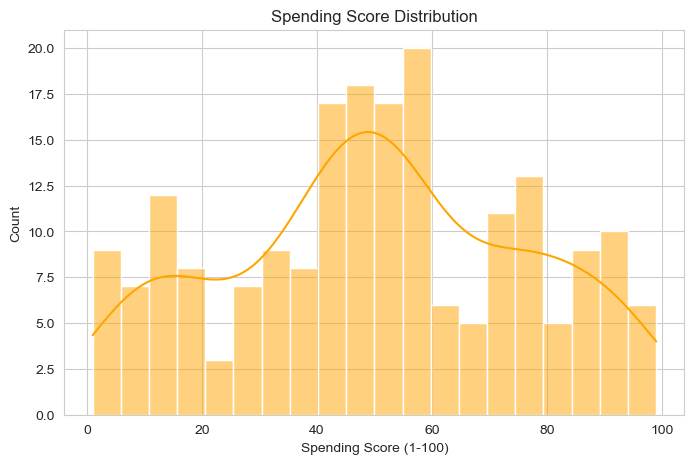

In [12]:
# Distribution of Spending Score
plt.figure(figsize=(8,5))

sns.histplot(df["Spending Score (1-100)"],
             bins=20,
             kde=True,
             color="orange")

plt.title("Spending Score Distribution")

plt.show()

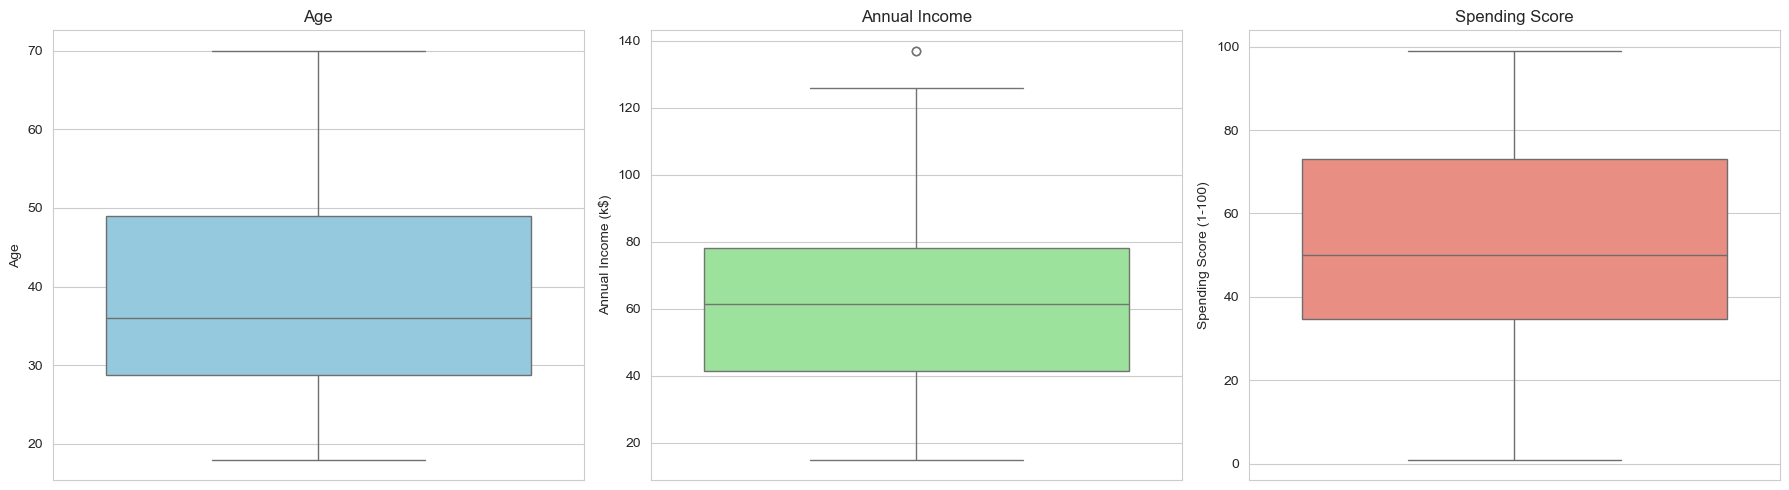

In [13]:
# Boxplots for Numerical Variables
fig, axes = plt.subplots(1,3,figsize=(18,5))

sns.boxplot(y=df["Age"], ax=axes[0], color="skyblue")
axes[0].set_title("Age")

sns.boxplot(y=df["Annual Income (k$)"], ax=axes[1], color="lightgreen")
axes[1].set_title("Annual Income")

sns.boxplot(y=df["Spending Score (1-100)"], ax=axes[2], color="salmon")
axes[2].set_title("Spending Score")

plt.tight_layout()

plt.show()

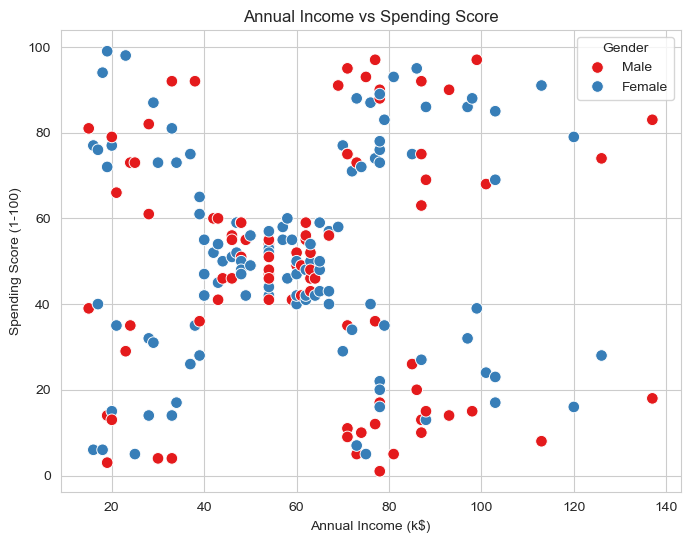

In [14]:
# Annual Income vs Spending Score
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender",
    palette="Set1",
    s=70
)

plt.title("Annual Income vs Spending Score")

plt.show()

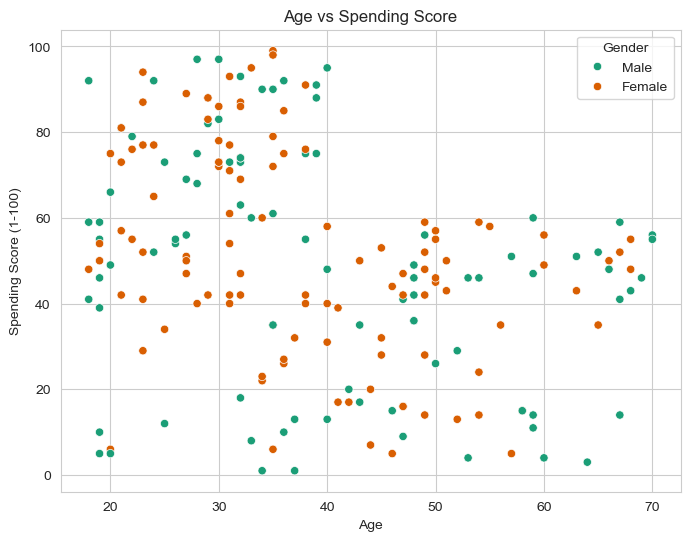

In [15]:
# Age vs Spending Score
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue="Gender",
    palette="Dark2"
)

plt.title("Age vs Spending Score")

plt.show()

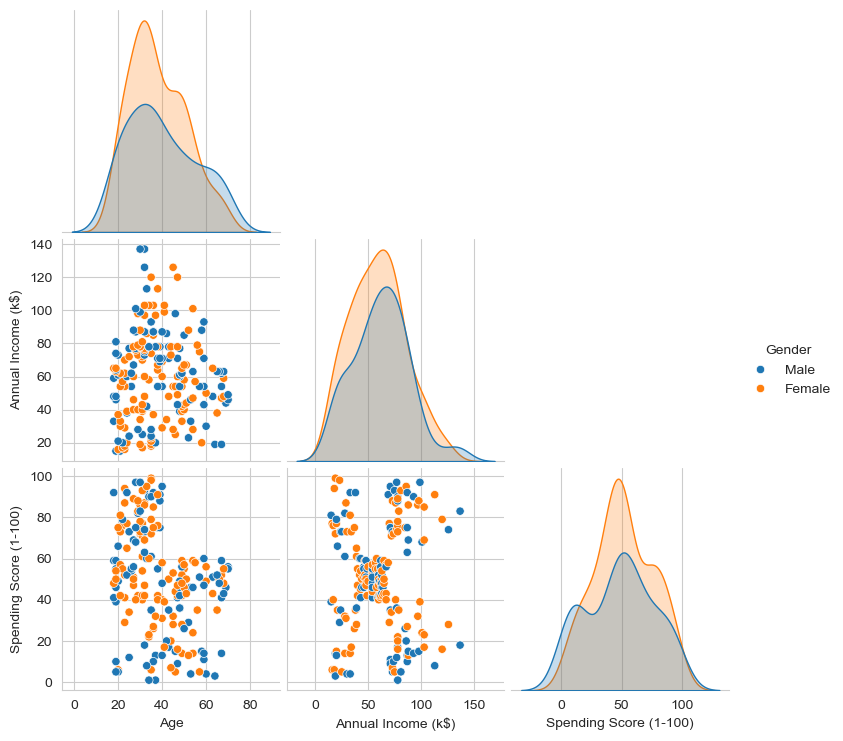

In [16]:
# Pairwise Relationships
sns.pairplot(
    df.drop(columns=["CustomerID"]),
    hue="Gender",
    corner=True
)

plt.show()

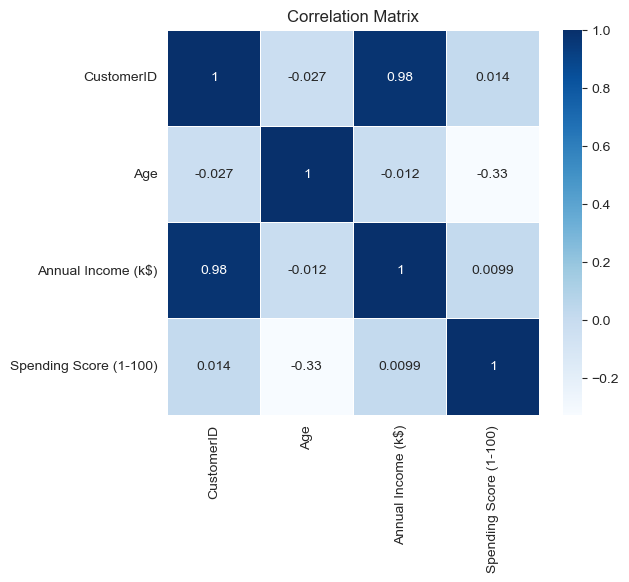

In [17]:
# Correlation Heatmap
plt.figure(figsize=(6,5))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

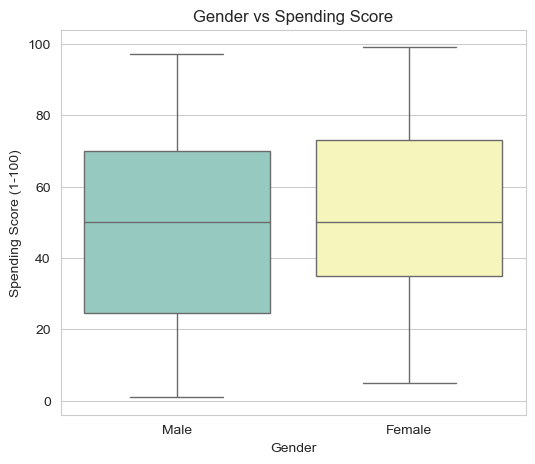

In [18]:
# Spending Score by Gender
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Spending Score (1-100)",
    palette="Set3"
)

plt.title("Gender vs Spending Score")

plt.show()

# Summary of Exploratory Data Analysis

### Key Findings

- No missing values or duplicate records were found.
- Customer ages are concentrated between 20 and 40 years.
- Spending scores vary widely across customers.
- Annual income is distributed across multiple levels.
- Scatter plots reveal naturally occurring customer groups.
- Younger customers generally exhibit higher spending behavior.
- The dataset is well suited for K-Means clustering.

The next step is to preprocess the data, determine the optimal number of clusters, and apply the K-Means algorithm for customer segmentation.

# Data Preprocessing

Before applying K-Means clustering, the data must be prepared.

K-Means is a distance-based algorithm, meaning variables with larger scales can dominate the clustering process. Therefore, numerical features are standardized using StandardScaler.

For customer segmentation, the most important features are:

- Annual Income (k$)
- Spending Score (1-100)

CustomerID is only an identifier and is excluded from analysis. Although Age and Gender are useful for profiling customers later, they are not used to create clusters in this implementation.

In [19]:
# Selecting Features
features = df[['Annual Income (k$)', 'Spending Score (1-100)']]

features.head()


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [20]:
# Feature Scaling
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

# Finding the Optimal Number of Clusters using the Elbow Method

The Elbow Method evaluates the Within Cluster Sum of Squares (WCSS).

As the number of clusters increases, WCSS decreases.

The best value of K is usually found where the curve begins to flatten, forming an "elbow."

In [21]:
wcss = []

for i in range(1, 11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    wcss.append(model.inertia_)

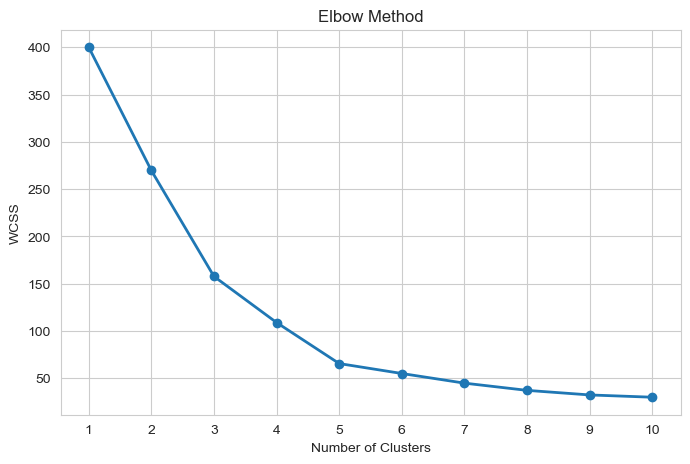

In [22]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss,
         marker='o',
         linewidth=2)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.xticks(range(1,11))

plt.show()

### Observation

The elbow appears around **K = 5**.

Therefore, five clusters will be used for customer segmentation.

# Validating the Number of Clusters using Silhouette Score

The Silhouette Score measures how well-separated clusters are.

Score Range:

- Close to 1 → Excellent clustering
- Around 0 → Overlapping clusters
- Negative → Poor clustering

In [23]:
silhouette_scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(scaled_features)

    score = silhouette_score(
        scaled_features,
        labels
    )

    silhouette_scores.append(score)

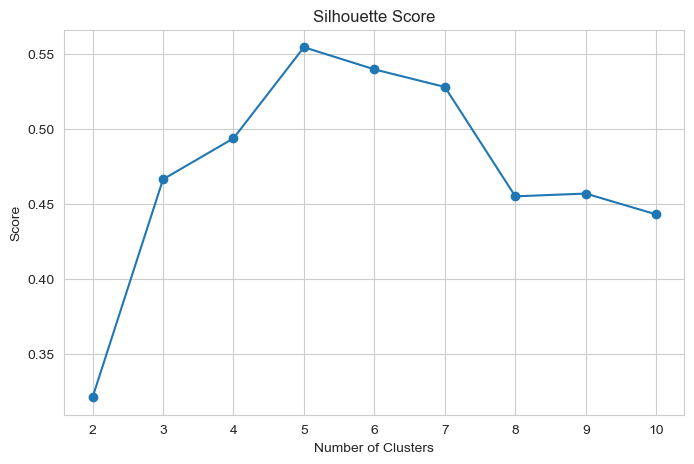

In [24]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11),
         silhouette_scores,
         marker='o')

plt.title("Silhouette Score")

plt.xlabel("Number of Clusters")

plt.ylabel("Score")

plt.show()

In [25]:
for k, score in zip(range(2,11), silhouette_scores):
    print(f"K = {k}: {score:.3f}")

K = 2: 0.321
K = 3: 0.467
K = 4: 0.494
K = 5: 0.555
K = 6: 0.540
K = 7: 0.528
K = 8: 0.455
K = 9: 0.457
K = 10: 0.443


### Observation
The Silhouette Score confirms that **five clusters** provide a good balance between compactness and separation.
This supports the result obtained using the Elbow Method.

# Building the K-Means Model

In [27]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_features)
## The K-Means algorithm assigns each customer to the nearest cluster centroid based on Euclidean distance.

In [28]:
## Assigning Cluster Labels
df['Cluster'] = clusters
df.head()
df['Cluster'].value_counts().sort_index()

#The dataset now includes a new column called **Cluster**, indicating the customer segment assigned by the K-Means algorithm.

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

In [29]:
# Cluster Centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers = pd.DataFrame(
    centers,
    columns=[
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
)

centers

#The cluster centers represent the average Annual Income and Spending Score of customers in each segment. These values help interpret the characteristics of each customer group.

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


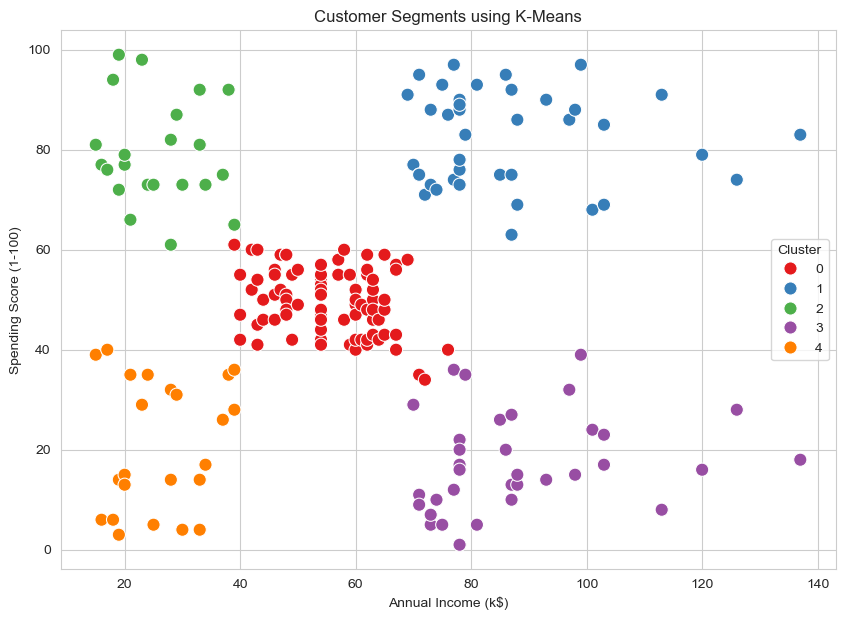

In [30]:
# Customer Segments Identified by K-Means
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=90
)

plt.title("Customer Segments using K-Means")

plt.show()

### Observation

The K-Means algorithm successfully separates customers into five distinct groups based on annual income and spending behavior.

The visualization shows clear boundaries between customer segments, indicating effective clustering.

# Cluster-wise Statistics

In [31]:
cluster_summary = df.groupby('Cluster').agg({
    'Age':'mean',
    'Annual Income (k$)':'mean',
    'Spending Score (1-100)':'mean',
    'CustomerID':'count'
})

cluster_summary.rename(columns={
    'CustomerID':'Number of Customers'
}, inplace=True)

cluster_summary.round(2)

,Age,Annual Income (k$),Spending Score (1-100),Number of Customers
Cluster,,,,
0,42.72,55.30,49.52,81
1,32.69,86.54,82.13,39
2,25.27,25.73,79.36,22
3,41.11,88.20,17.11,35
4,45.22,26.30,20.91,23


### Key Insights

The cluster summary provides valuable information about the average age, income, and spending behavior of each customer segment.

These statistics will be used in the next section to develop customer personas and targeted marketing strategies.

# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms high-dimensional data into a smaller number of dimensions while retaining most of the important information.

Although K-Means was trained using standardized income and spending score, PCA allows us to visualize customer clusters in a two-dimensional space.

In [32]:
pca = PCA(n_components=2, random_state=42)

pca_features = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(
    pca_features,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = df['Cluster']

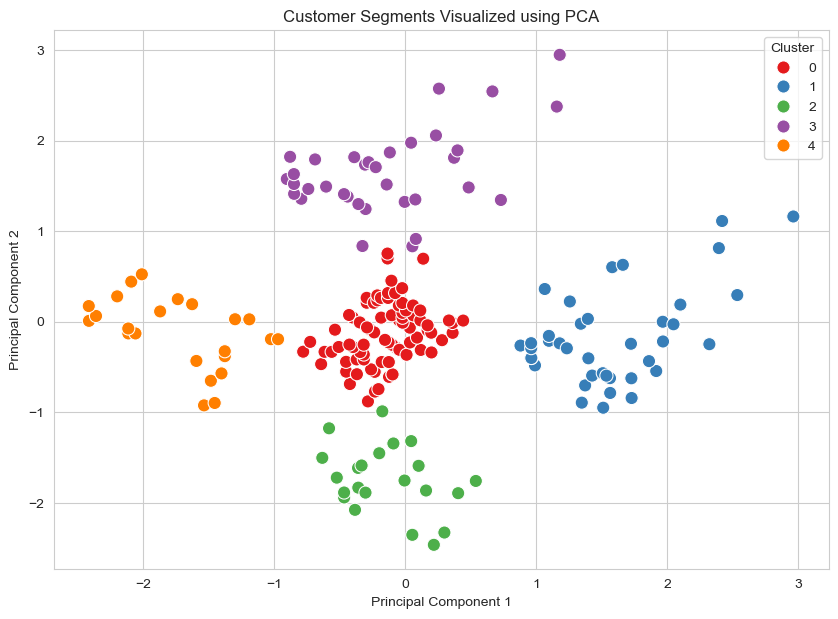

In [33]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=90
)

plt.title("Customer Segments Visualized using PCA")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

### Observation

The PCA visualization shows that the five clusters are reasonably well separated.

Customers within the same cluster exhibit similar spending behavior and income levels, while different clusters occupy distinct regions in the feature space.

# t-SNE Visualization

t-SNE (t-distributed Stochastic Neighbor Embedding) is another dimensionality reduction technique that preserves local neighborhood relationships better than PCA.

It is commonly used for visualizing clusters in machine learning projects.

In [34]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

tsne_features = tsne.fit_transform(scaled_features)

tsne_df = pd.DataFrame(
    tsne_features,
    columns=['Dimension1','Dimension2']
)

tsne_df['Cluster'] = df['Cluster']

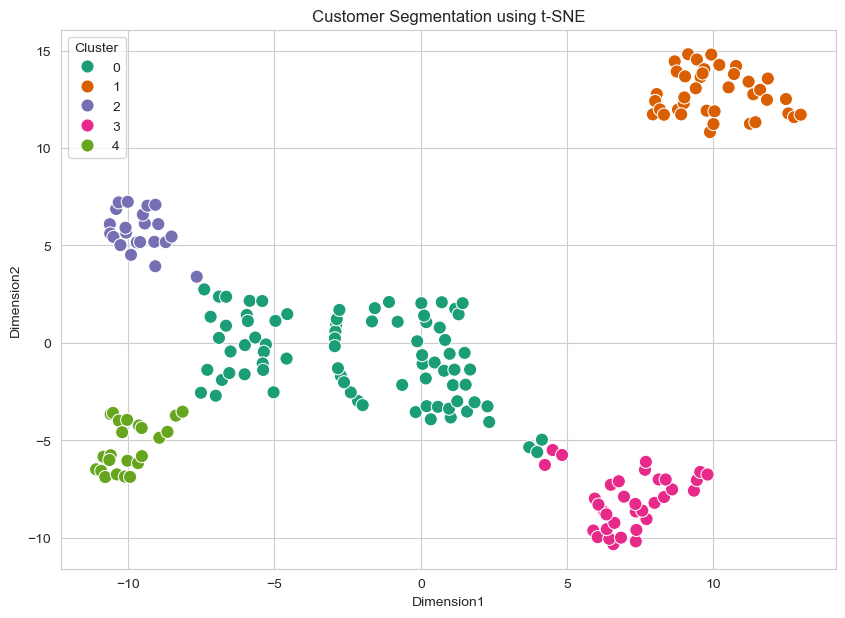

In [35]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=tsne_df,
    x='Dimension1',
    y='Dimension2',
    hue='Cluster',
    palette='Dark2',
    s=90
)

plt.title("Customer Segmentation using t-SNE")

plt.show()

### Observation

Compared to PCA, t-SNE provides an even clearer visualization of customer groups.

This confirms that the K-Means algorithm has successfully discovered meaningful customer segments.

# Marketing Strategies and Business Insights

Based on the K-Means clustering results, the customers were segmented into five distinct groups according to their annual income and spending behavior. These segments provide valuable insights that can help businesses design targeted marketing campaigns and improve customer engagement.

## Segment 1: High Income – High Spending Customers

These customers are the most valuable to the business as they generate high revenue and frequently make purchases.

**Marketing Strategy**
- Offer VIP memberships and exclusive rewards.
- Provide early access to new products and premium services.
- Send personalized recommendations based on purchase history.
- Organize exclusive events and loyalty programs to retain these customers.


## Segment 2: High Income – Low Spending Customers

These customers have strong purchasing power but currently spend less than expected.

**Marketing Strategy**
- Encourage spending through personalized discounts and special promotions.
- Recommend premium products that match their interests.
- Offer limited-time offers and exclusive coupons.
- Use targeted email campaigns to increase engagement.

## Segment 3: Low Income – High Spending Customers

These customers spend actively despite having relatively lower income.

**Marketing Strategy**
- Introduce bundle offers and seasonal discounts.
- Reward frequent purchases through loyalty points.
- Promote affordable products with attractive offers.
- Encourage repeat purchases using cashback or referral programs.

## Segment 4: Low Income – Low Spending Customers

These customers contribute the least to overall sales and are generally price-sensitive.

**Marketing Strategy**
- Focus on budget-friendly products.
- Offer discount campaigns and promotional sales.
- Use cost-effective digital marketing channels.
- Increase awareness through value-based promotions.

## Segment 5: Moderate Income – Moderate Spending Customers

These customers represent a stable customer base with balanced purchasing behavior.

**Marketing Strategy**
- Encourage repeat purchases through loyalty programs.
- Promote complementary products using cross-selling techniques.
- Offer personalized recommendations based on previous purchases.
- Maintain customer engagement through regular promotional campaigns.

# Overall Business Insights

The customer segmentation analysis reveals that customers exhibit different purchasing behaviors and spending patterns. Rather than applying the same marketing strategy to every customer, businesses can improve marketing efficiency by targeting each customer segment with personalized offers.

Key insights from this analysis include:

- High-income customers are not always high spenders, indicating opportunities for personalized marketing.
- Younger customers generally demonstrate higher spending behavior than older customers.
- Premium customers should be prioritized through retention strategies because they contribute significantly to revenue.
- Price-sensitive customers respond better to discounts and promotional campaigns.
- Customer segmentation enables businesses to optimize marketing budgets, improve customer satisfaction, increase customer retention, and maximize overall profitability.

Overall, K-Means clustering provides an effective approach for understanding customer behavior and supports data-driven decision-making for targeted marketing strategies.